In [2]:
import gymnasium as gym
import math
import matplotlib.pyplot as plt

In [3]:
env = gym.make("CartPole-v1")

In [4]:
class Node:
    def __init__(self, parent=None, action=None):
        self.parent = parent
        self.action = action
        self.children = []
        self.visits = 1
        self.reward = 0

In [5]:
def ucb(n, total):
    return n.reward/n.visits + math.sqrt(2*math.log(total)/n.visits)

In [6]:
def backpropagate(node, reward):

    while node:
        node.visits += 1
        node.reward += reward
        node = node.parent

In [7]:
def simulate(action):

    sim_env = gym.make("CartPole-v1")

    s, _ = sim_env.reset()

    total_reward = 0

    for _ in range(30):

        s, r, d, t, _ = sim_env.step(action)

        total_reward += r

        if d or t:
            break

    sim_env.close()

    return total_reward

In [8]:
rewards = []
lengths = []

for ep in range(20):

    state, _ = env.reset()

    root = Node()

    for a in [0, 1]:

        child = Node(root, a)

        result = simulate(a)

        backpropagate(child, result)

        root.children.append(child)

    best = max(root.children, key=lambda x: ucb(x, root.visits))

    total_reward = 0
    steps = 0

    s, _ = env.reset()
    done = False

    while not done:

        s, r, done, trunc, _ = env.step(best.action)

        total_reward += r
        steps += 1

        if done or trunc:
            break

    rewards.append(total_reward)
    lengths.append(steps)

    print(f"Episode {ep+1} Reward={total_reward} Length={steps}")

Episode 1 Reward=9.0 Length=9
Episode 2 Reward=10.0 Length=10
Episode 3 Reward=9.0 Length=9
Episode 4 Reward=8.0 Length=8
Episode 5 Reward=8.0 Length=8
Episode 6 Reward=10.0 Length=10
Episode 7 Reward=10.0 Length=10
Episode 8 Reward=9.0 Length=9
Episode 9 Reward=8.0 Length=8
Episode 10 Reward=10.0 Length=10
Episode 11 Reward=9.0 Length=9
Episode 12 Reward=10.0 Length=10
Episode 13 Reward=9.0 Length=9
Episode 14 Reward=9.0 Length=9
Episode 15 Reward=9.0 Length=9
Episode 16 Reward=8.0 Length=8
Episode 17 Reward=9.0 Length=9
Episode 18 Reward=9.0 Length=9
Episode 19 Reward=8.0 Length=8
Episode 20 Reward=10.0 Length=10


Average Reward = 9.05


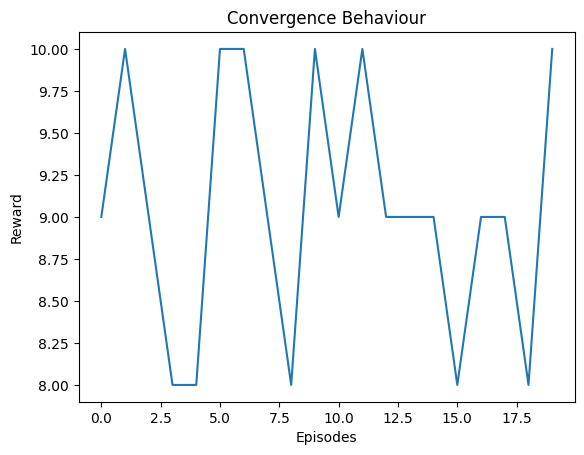

In [9]:
print("Average Reward =", sum(rewards)/len(rewards))

plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Convergence Behaviour")
plt.show()